# Notebook For Figure S04 Method Paper

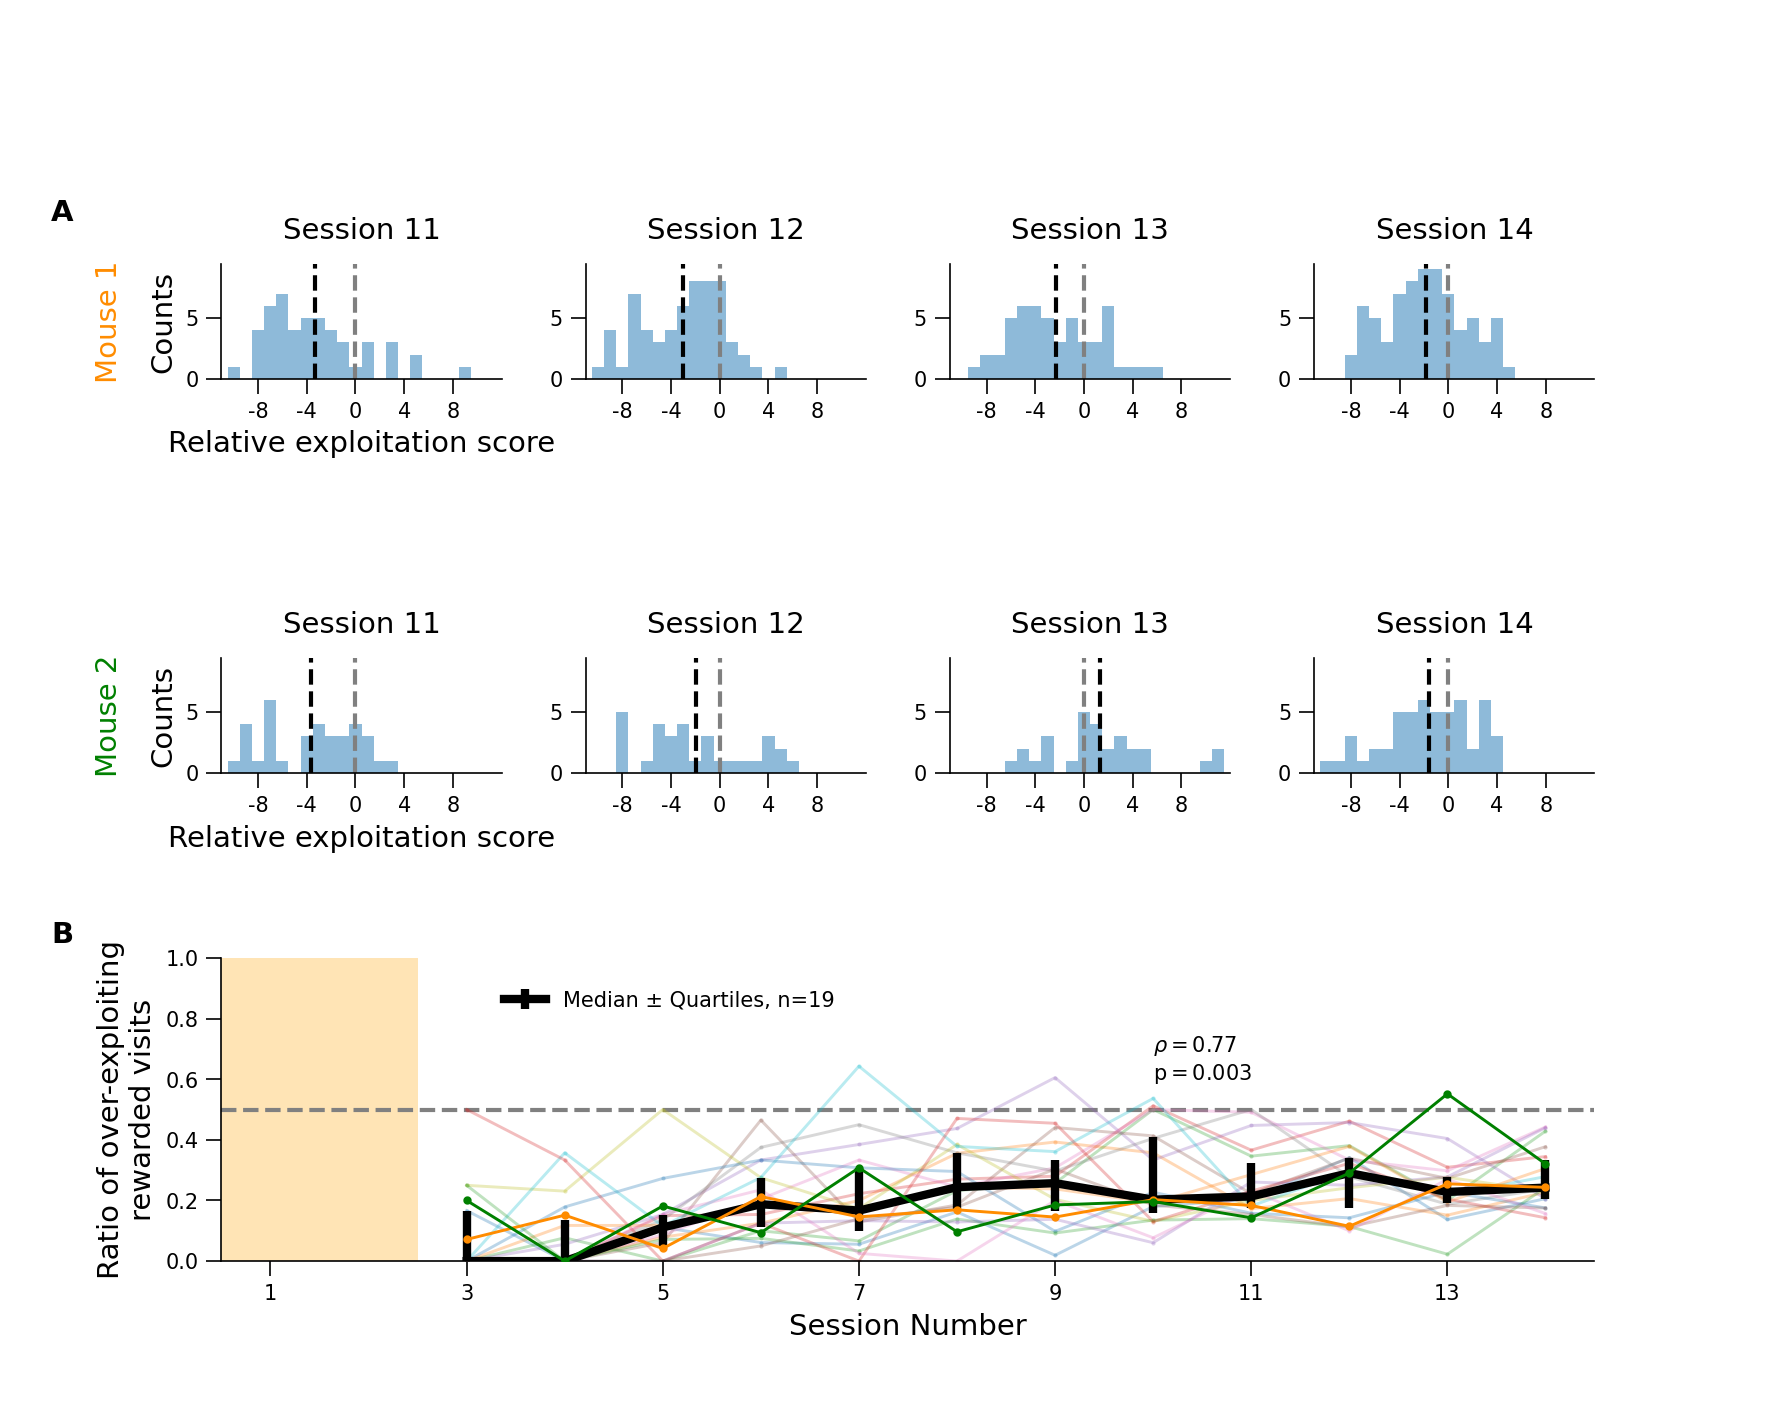

In [ ]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS04.png")
display(img)


# 1. Importing necessary libraries and general functions  

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import matplotlib.patches as patches
import numpy as np
import pickle
import similaritymeasures as sm
from scipy.stats import spearmanr
from bisect import bisect
plt.style.use('paper.mplstyle')



In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

# path_to_data_folder='/home/tom/Thèse/Data/ForagingMice/4TowerTaskMethodPaper/Group1Data/'
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
path_to_data_folder = '/home/tom/Code/tower_foraging_park_data/Group1Data'

# Analysing the entire group of mice
mice_to_analyse = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]


# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,14]
# Select the number of sessions that will be in statistics
first_and_last_session_indexes_stats = [2,14]
# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set.
session_index_offset = first_and_last_session_indexes[0]

All mice folders are present in data folder.
 19 mice will be analysed



# 3. Chosing illustration mice and sessions  

In [5]:
# Chose the 2 mice that are highlighted in statistics across figures
illustration_mice = ['MOUEml1_8', 'MOUEml1_5']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]

# 4. General functions

In [6]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54


def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index):
    
    """
    Determines the rewarded direction for the session corresponding to the input index of a given mouse. 
    This index is relative to the session position in the series of analysed sessions.
    This input index can have an offset. This is usefull if the sessions series analysed does not start with the first session. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs or if both directions are rewarded.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
        
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Clockwise and Counterclockwise

        # Returns None if the rewarded direction entry in session_param_df is not recognized
        else:
            print('ERROR: Unexpected rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction



In [7]:
def order_runs(all_epochs):

    ordered_all_runs = []
    ordered_all_runs_frames = []

    for k in all_epochs.keys():

        if k != 'immobility':

            for i in range(len(all_epochs[k])):

                ordered_all_runs.append(all_epochs[k][i])
                ordered_all_runs_frames.append(all_epochs[k][i][0])

    ordered_all_runs_frames = sorted(ordered_all_runs_frames, key=lambda x: x[0])
    
    ordered_all_runs = sorted(ordered_all_runs,key=lambda x: x[0])

    return ordered_all_runs, ordered_all_runs_frames

def define_visits(all_epochs):

    visits = []

    n = -1

    runs_around_tower = all_epochs['run_around_tower']

    temp_all_epochs = all_epochs.copy()
    temp_all_epochs['run_around_tower'] = runs_around_tower

    ordered_all_runs, ordered_all_runs_frames = order_runs(temp_all_epochs)


    for i, run_around_tower in enumerate(runs_around_tower):

        is_good_turn = run_around_tower[3]['Rewarded']
        max_rewards = run_around_tower[3]['max_rewards']

        ordered_idx = ordered_all_runs_frames.index(run_around_tower[0])

        departure, arrival = [ordered_all_runs[ordered_idx-1][1][0],ordered_all_runs[ordered_idx-1][2][0]] if ordered_idx !=0 else ['','']

        previous_run_not_a_turn = (departure != arrival) or len(visits)==0
        previous_run_started_elsewhere = ordered_all_runs[ordered_idx-1][1][0] != ordered_all_runs[ordered_idx][1][0]

        if previous_run_not_a_turn or previous_run_started_elsewhere:

            n = n + 1

            visits.append({})

            visits[n]['turns'] = 1
            visits[n]['rewarded_turns'] = int(is_good_turn)
            visits[n]['max_reward'] = max_rewards
            visits[n]['patch'] = run_around_tower[1][0] #patch
            visits[n]['visit_time'] = run_around_tower[4]['epoch_time']
            visits[n]['turns_time'] = [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = [run_around_tower[4]['epoch_duration']]
            visits[n]['is_last_turn_rewarded'] = is_good_turn

        else:
            
            visits[n]['rewarded_turns'] += int(is_good_turn)
            visits[n]['turns'] += 1
            visits[n]['turns_time'] = visits[n]['turns_time'] + [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = visits[n]['turns_duration'] + [run_around_tower[4]['epoch_duration']]
            visits[n]['is_last_turn_rewarded'] = is_good_turn
            

    return visits

def compute_turns_per_visit(folder_path_mouse_to_analyse, session_index):

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[session_index]

    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_analyse, session_index)
            
    # Load the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)
        
    visit = define_visits(session_data['all_epochs'])

    turns_per_visit = []
    rewarded_turns_per_visit = []
    visits_time = []
    max_rewards = []
    is_last_turn_rewarded_per_visit = []

    for i in range(len(visit)):

        if rewarded_direction=='X':

            nb_of_turns = visit[i]['turns']
            nb_of_rewarded_turns = np.nan
            visit_time = visit[i]['visit_time']
            max_reward = np.nan
            is_last_turn_rewarded = np.nan #visit[i]['is_last_turn_rewarded']
            
        else:
            
            nb_of_turns = visit[i]['turns']
            nb_of_rewarded_turns = visit[i]['rewarded_turns']
            visit_time = visit[i]['visit_time']
            max_reward = visit[i]['max_reward'] if visit[i]['max_reward']!=1 else np.nan
            is_last_turn_rewarded = visit[i]['is_last_turn_rewarded']

        turns_per_visit.append(nb_of_turns)
        rewarded_turns_per_visit.append(nb_of_rewarded_turns)
        visits_time.append(visit_time)
        max_rewards.append(max_reward)
        is_last_turn_rewarded_per_visit.append(is_last_turn_rewarded)

    return [np.array(turns_per_visit),np.array(rewarded_turns_per_visit),np.array(visits_time),np.array(max_rewards), np.array(is_last_turn_rewarded_per_visit)]




In [8]:
def define_csv_visits(df):

    n = -1
    visits = []

    for i in range(len(df)):
        
        previous_transition_in_other_patch = df.currentPatch[i] != df.currentPatch[i-1] if i>0 else True
        previous_cumulated_rewards_higher = df.nberOfConsecRewards[i] < df.nberOfConsecRewards[i-1] if i>0 else True
        previous_cumulated_rewards_zero = df.nberOfConsecRewards[i-1]==0 if i>0 else True
        left_tower_after_previous_transition = previous_cumulated_rewards_higher and previous_cumulated_rewards_zero 
        # previous_max_reward_different = df.maxNberOfConsecRewards[i-1] != df.maxNberOfConsecRewards[i]

        if previous_transition_in_other_patch or left_tower_after_previous_transition:

            n = n + 1   
            visits.append({})

            visits[n]['transitions'] = 1
            visits[n]['rewarded_transitions'] = int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['max_reward'] = df.maxNberOfConsecRewards[i]
            visits[n]['patch'] = df.currentPatch[i]
            visits[n]['first_transition_time'] = df.time[i]
            visits[n]['transitions_time'] = [df.time[i]]
            visits[n]['transitions_reward_status'] = [df.Rewarded[i]]
        
        else:

            visits[n]['transitions'] += 1
            visits[n]['rewarded_transitions'] += int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['transitions_time'] = visits[n]['transitions_time'] + [df.time[i]]
            visits[n]['transitions_reward_status'] = visits[n]['transitions_reward_status'] + [df.Rewarded[i]]

    return visits

def find_rewarded_csv_visit(visits):
    
    rewarded_visits = []

    for visit in visits:

        if visit['rewarded_transitions']>0:
            rewarded_visits.append(visit)

    return rewarded_visits

def check_is_transition_in_pickle_visit(csv_visit,pickle_visit):

    for transition_time in csv_visit['transitions_time']:

        for i in range(len(pickle_visit['turns_time'])):

            turn_start_time = pickle_visit['turns_time'][i]
            turn_end_time = pickle_visit['turns_time'][i] + pickle_visit['turns_duration'][i]

            if turn_start_time<=transition_time and transition_time<=turn_end_time:

                return True
    
    return False

def pair_csv_pickle_visits(csv_visits, pickle_visits):

    kept_visits = []

    pickle_visits_temp = copy.deepcopy(pickle_visits)
    csv_visits_temp = copy.deepcopy(csv_visits)
    while len(pickle_visits_temp)>0:
        
        pickle_visit = pickle_visits_temp[0]
        
        for i, csv_visit in enumerate(csv_visits_temp):

            is_transition_in_pickle_visit = check_is_transition_in_pickle_visit(csv_visit, pickle_visit)
        
            if is_transition_in_pickle_visit:

                kept_visits.append(csv_visit)

                pickle_visits_temp.pop(0)
                break
        
    return kept_visits

def compute_turns_per_rewarded_csv_visit(visit):

    turns_per_visit = []
    rewarded_turns_per_visit = []
    visits_time = []
    max_rewards = []

    for i in range(len(visit)):

        if i<2:

            nb_of_turns = visit[i]['transitions']
            nb_of_rewarded_turns = np.nan
            visit_time = visit[i]['first_transition_time']
            max_reward = np.nan

        else:
            
            nb_of_turns = visit[i]['transitions']
            nb_of_rewarded_turns = visit[i]['rewarded_transitions']
            visit_time = visit[i]['first_transition_time']
            max_reward = visit[i]['max_reward'] if visit[i]['max_reward']!=1 else np.nan

        turns_per_visit.append(nb_of_turns)
        rewarded_turns_per_visit.append(nb_of_rewarded_turns)
        visits_time.append(visit_time)
        max_rewards.append(max_reward)

    return [np.array(turns_per_visit),np.array(rewarded_turns_per_visit),np.array(visits_time),np.array(max_rewards)]

In [9]:
# Initialize the dictionary with empty lists for each mouse

mouse_overexploit_rewarded_visit_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)
    
    # Get the list of sessions
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_analyse)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_analyse, '\n')

    # analyse each session
    for session_index,session_to_analyse in enumerate(sessions_to_analyse):

        # Define the pickle file path
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)
                
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_analyse}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mouse_overexploit_rewarded_visit_persession[mouse].append([session_index+1, np.nan])

            continue  # Skip to the next session if the pickle file does not exist
        
        # Load the session data from the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        turns_df = pd.read_csv(os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_turnsinfo.csv'))

        pickle_visits = define_visits(session_data['all_epochs'])
        rewarded_pickle_visits = [pickle_visit for pickle_visit in pickle_visits if pickle_visit['rewarded_turns']>0]
        csv_visits = define_csv_visits(turns_df)
        rewarded_csv_visits = find_rewarded_csv_visit(csv_visits)
        paired_rewarded_csv_visits = pair_csv_pickle_visits(rewarded_csv_visits, rewarded_pickle_visits)
        
        turns_per_visit,rewarded_turns_per_visit,visits_time,max_rewards = compute_turns_per_rewarded_csv_visit(paired_rewarded_csv_visits)        
        # turns_per_rewarded_visit = np.where(np.logical_not(np.equal(rewarded_turns_per_visit,0)),turns_per_visit,np.nan)
        # turns_per_rewarded_visit = np.where(np.logical_not(np.isnan(rewarded_turns_per_visit)),turns_per_rewarded_visit,np.nan)

        nbr_overexploit_visits = 0
        nbr_of_visit = 0
        for csv_visit, pickle_visit in zip(paired_rewarded_csv_visits, rewarded_pickle_visits):

            nbr_of_visit += 1
            transitions = csv_visit['transitions']

            # Remove the last transition if it happened during departure of the tower
            if csv_visit['transitions_time'][-1]>pickle_visit['turns_time'][-1]+pickle_visit['turns_duration'][-1]:
                transitions = transitions - 1
            
            nbr_overexploit_visits += 1 if csv_visit['max_reward']<transitions else 0 
            # nbr_overexploit_visits += 1 if visit['rewarded_transitions']<visit['transitions'] else 0

        if nbr_of_visit==0 or session_index<2:
            overexploit_ratio = np.nan
        else:
            overexploit_ratio = nbr_overexploit_visits/nbr_of_visit

        mouse_overexploit_rewarded_visit_persession[mouse].append([session_index+1, overexploit_ratio])

Mouse MOUEml1_5. There is/are 14 sessions:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Mouse MOUEml1_8. There is/are 14 sessions:
['MOUEml1_8_20230420-1740', 'MOUEml1_8_20230421-1132', 'MOUEml1_8_20230422-1145', 'MOUEml1_8_20230422-1748', 'MOUEml1_8_20230423-1156', 'MOUEml1_8_20230423-1725', 'MOUEml1_8_20230424-1118', 'MOUEml1_8_20230424-1724', 'MOUEml1_8_20230425-1119', 'MOUEml1_8_20230425-1740', 'MOUEml1_8_20230426-1137', 'MOUEml1_8_20230426-1720', 'MOUEml1_8_20230427-1146', 'MOUEml1_8_20230427-1708'] 

Mouse MOUEml1_11. There is/are 14 sessions:
['MOUEml1_11_20230420-1906', 'MOUEml1_11_20230421-1239', 'MOUEml1_11_20230422-1250', 'MOUEml1_11_20230422-18

## 5. Panel A

In [10]:
def plot_diff_distribution(folder_path_mouse_to_analyse, session_index, ax, show_xlabel=True, show_ylabel=True):

    """
    Plots 
    
    Arguments:
        
    """

    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[session_index]

    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)
    
    turns_df = pd.read_csv(os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_turnsinfo.csv'))

    pickle_visits = define_visits(session_data['all_epochs'])
    rewarded_pickle_visits = [pickle_visit for pickle_visit in pickle_visits if pickle_visit['rewarded_turns']>0]

    csv_visits = define_csv_visits(turns_df)
    rewarded_csv_visits = find_rewarded_csv_visit(csv_visits)
    paired_rewarded_csv_visits = pair_csv_pickle_visits(rewarded_csv_visits, rewarded_pickle_visits)
    
    diff_list = []

    for i in range(len(paired_rewarded_csv_visits)):

        transitions = paired_rewarded_csv_visits[i]['transitions']
        
        # Remove the last transition if it happened during departure of the tower
        if paired_rewarded_csv_visits[i]['transitions_time'][-1]>rewarded_pickle_visits[i]['turns_time'][-1]+rewarded_pickle_visits[i]['turns_duration'][-1]:
            transitions = transitions - 1

        diff = transitions - paired_rewarded_csv_visits[i]['max_reward']

        diff_list.append(diff)

    n_bins = np.arange(np.nanmin(diff_list)-1,np.nanmax(diff_list)+1)+0.5
    ax.hist(diff_list, bins=n_bins, alpha=0.5, label='')
    ax.axvline(ymax=20, linestyle='--', color='grey')
    ax.axvline(np.nanmean(diff_list),ymax=20, linestyle='--', color='k')
    
    if show_xlabel:
        ax.set_xlabel('Relative exploitation score')
    if show_ylabel:
        ax.set_ylabel('Counts')

    ax.set_xticks(np.arange(-12,12,step=4))
    ax.set_xlim((np.nanmin(diff_list)-1,np.nanmax(diff_list)+1))    



MOUEml1_8
MOUEml1_5


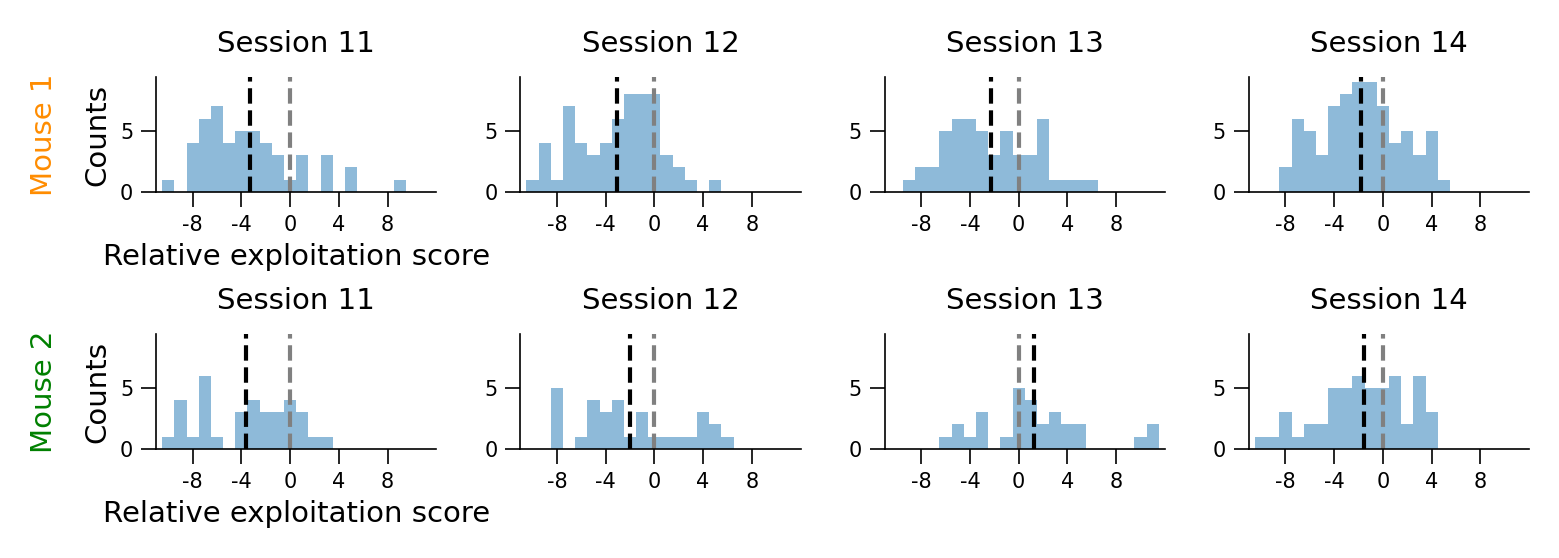

In [11]:
illustration_sessions_indexes = [10,11,12,13]

fig=plt.figure(figsize=(cm2inch(15), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(2, 1 , hspace=0.3)

row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
row2 = gs[1].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
rows = [row1,row2]

ax_lists = [[],[]]

max_xlim = [0,0]
max_ylim = [0,0]

for n, mouse in enumerate(illustration_mice):

    print(mouse)
    
    for i in range(len(illustration_sessions_indexes)):


        ax = plt.subplot(rows[n][i], aspect="equal")
        ax_lists[n].append(ax)

        plot_diff_distribution(os.path.join(path_to_data_folder, mouse), illustration_sessions_indexes[i], ax, 
                                            show_xlabel=True if i==0 else False, show_ylabel=True if i==0 else False)
        
        ax.set_title(f"Session {illustration_sessions_indexes[i]+1}", fontsize=7)

        current_xlim = ax.get_xlim()
        current_ylim = ax.get_ylim()

        max_xlim = [min(current_xlim[0],max_xlim[0]), max(current_xlim[1],max_xlim[1])]
        max_ylim = [0, max(current_ylim[1],max_ylim[1])]

        if i==0:
            ax.text(-0.4, 0.5, f'Mouse {n+1}',
                    color=illustration_colors[n],rotation=90, va='center', ha='center',
                    transform=ax.transAxes, fontsize=7)

for n in range(len(illustration_mice)):

    for ax in ax_lists[n]:

        ax.set_xlim(max_xlim)
        ax.set_ylim(max_ylim)



## 6. Panel B

In [12]:
def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None], highlight_colors = ["darkorange", "green"], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, show_fam=False, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_legend=True, legend_loc=(0.05, 0.9)):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        show_fam (bool): Toggle the display of familiarization sessions label
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
        legend_loc (tupple, optional): Location of the legend.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    mice_to_plot = copy.deepcopy(mice_list)

    # Ensure that the mice to hihlight will be plotted and displayed on the legend in order
    if len(mice_to_highlight)>0:

        mice_to_plot.remove(mice_to_highlight[0])
        mice_to_plot.remove(mice_to_highlight[1])

        mice_to_plot = mice_to_highlight + mice_to_plot
    
    # Loop through each mouse and gather session data

    for mouse in mice_to_plot:

        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Check if there is a nan value in the values list and remove it to allow plotting of lines between points with values
        if sum(np.isnan(x) for x in values)>0:

            session_indices_array=np.array(session_indices)
            values_array=np.array(values)
            mask = ~np.isnan(values_array)
            session_indices=session_indices_array[mask]
            values=values_array[mask]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:

            if mouse == mice_to_highlight[0]:
                color = highlight_colors[0]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[0], zorder=100*len(median_color))

            elif mouse == mice_to_highlight[1]: 
                color = highlight_colors[1]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[1], zorder=100*len(median_color))
            
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linewidth=0.7, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    ylimits = ax.get_ylim()  # Get the current y-limits
    rectangle_height = abs(ylimits[1]-ylimits[0])  # Calculate the height of the rectangle


    # Define the rectangle position and size
    rect = patches.Rectangle((0.5, ylimits[0]), 2, rectangle_height, color='moccasin', alpha=1, lw=0, zorder=-np.inf)  # (x_start, y_start), width, height

    # Add rectangle to the plot
    ax.add_patch(rect)

    if show_fam:
        # Add text label on top of the rectangle
        ax.text(1.5, ylimits[1], "Fam.", fontsize=6, ha='center', va='bottom', fontweight='normal',color='orange', alpha=0.6)

    # Show legend if required
    if show_legend:

        ax.legend(frameon=False, loc=legend_loc, )


def shuffled_spearman_test(mouse_values_persession, shuffle_number, hypothesis, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the Spearman correlation coefficients from shuffled data will be stored. 
    # This will be the null distribution of Spearman correlation coefficient
    spearman_rho_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            session_indices = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)

        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        # Compute the Spearman correlation coefficient of the median
        spearman_result = spearmanr(session_indices, median_values)
        # Store the coefficient
        spearman_rho_list.append(spearman_result[0])
    
    ### Compute the Spearman correlation coefficient of unshuffled data ###

    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        session_indices = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Compute the Spearman correlation coefficient of the median
    actual_spearman_result = spearmanr(session_indices,actual_median_values, nan_policy='omit')
    actual_rho = actual_spearman_result[0]

    # Compute the p-value corresponding to the tested hypothesis
    if hypothesis=="increasing":
        # Computing the the proportion of the null distribution above the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), actual_rho):])/len(spearman_rho_list)
    elif hypothesis=="decreasing":
        # Computing the the proportion of the null distribution below the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[:bisect(np.sort(spearman_rho_list), actual_rho)])/len(spearman_rho_list)
    else:
        # Raise an error if no valid hypothesis was made
        print("ERROR : Invalid hypothesis. Please specify increasing or decreasing")
        return

    return actual_rho, p_value

def plot_shuffled_spearman_test_res(ax, text_loc, mouse_values_persession, n_shuffles, hypothesis, color='black', illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    test_res = shuffled_spearman_test(mouse_values_persession, n_shuffles, hypothesis, illustration_mouse_name=illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)    

    if test_res[1]==0:
        
        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ < 0.001$', fontsize=5, color=color) 

    else:

        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ = {round(test_res[1],3)}$', fontsize=5, color=color)

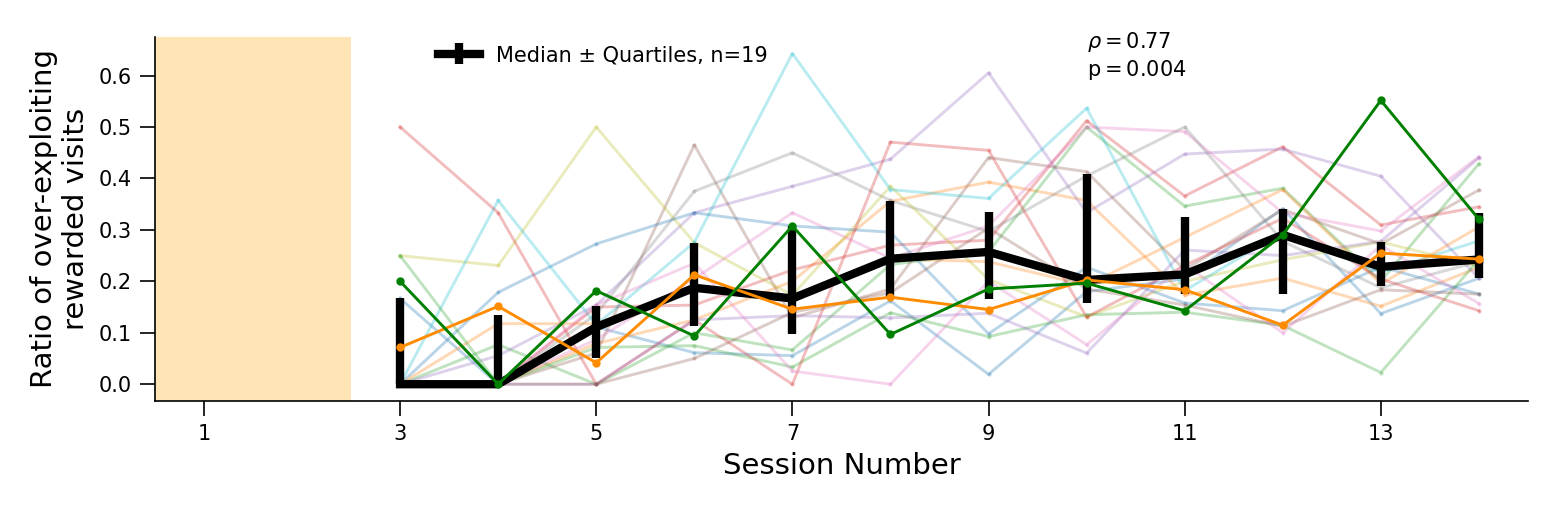

In [13]:
fig=plt.figure(figsize=(cm2inch(15), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(1, 1 , hspace=0.3)

row3 = gs[0].subgridspec(1, 1)
ax3 = plt.subplot(row3[0,0])

plot_learning_curves(mouse_overexploit_rewarded_visit_persession, ax3, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, median_color= 'k', show_xlabel = True, xlim=xlim_stats, ylabel='Ratio of over-exploiting\nrewarded visits', main_line_label=f"Median ± Quartiles, n={len(mice_to_analyse)}", tick_interval=2, index_offset=session_index_offset, show_legend=True, legend_loc=(0.2,0.9))
plot_shuffled_spearman_test_res(ax3, (10,0.6), mouse_overexploit_rewarded_visit_persession, 1000, 'increasing', color='k', first_and_last_session_indexes=first_and_last_session_indexes_stats)




## 7. Whole figure

/tmp/ipykernel_29290/2220954145.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


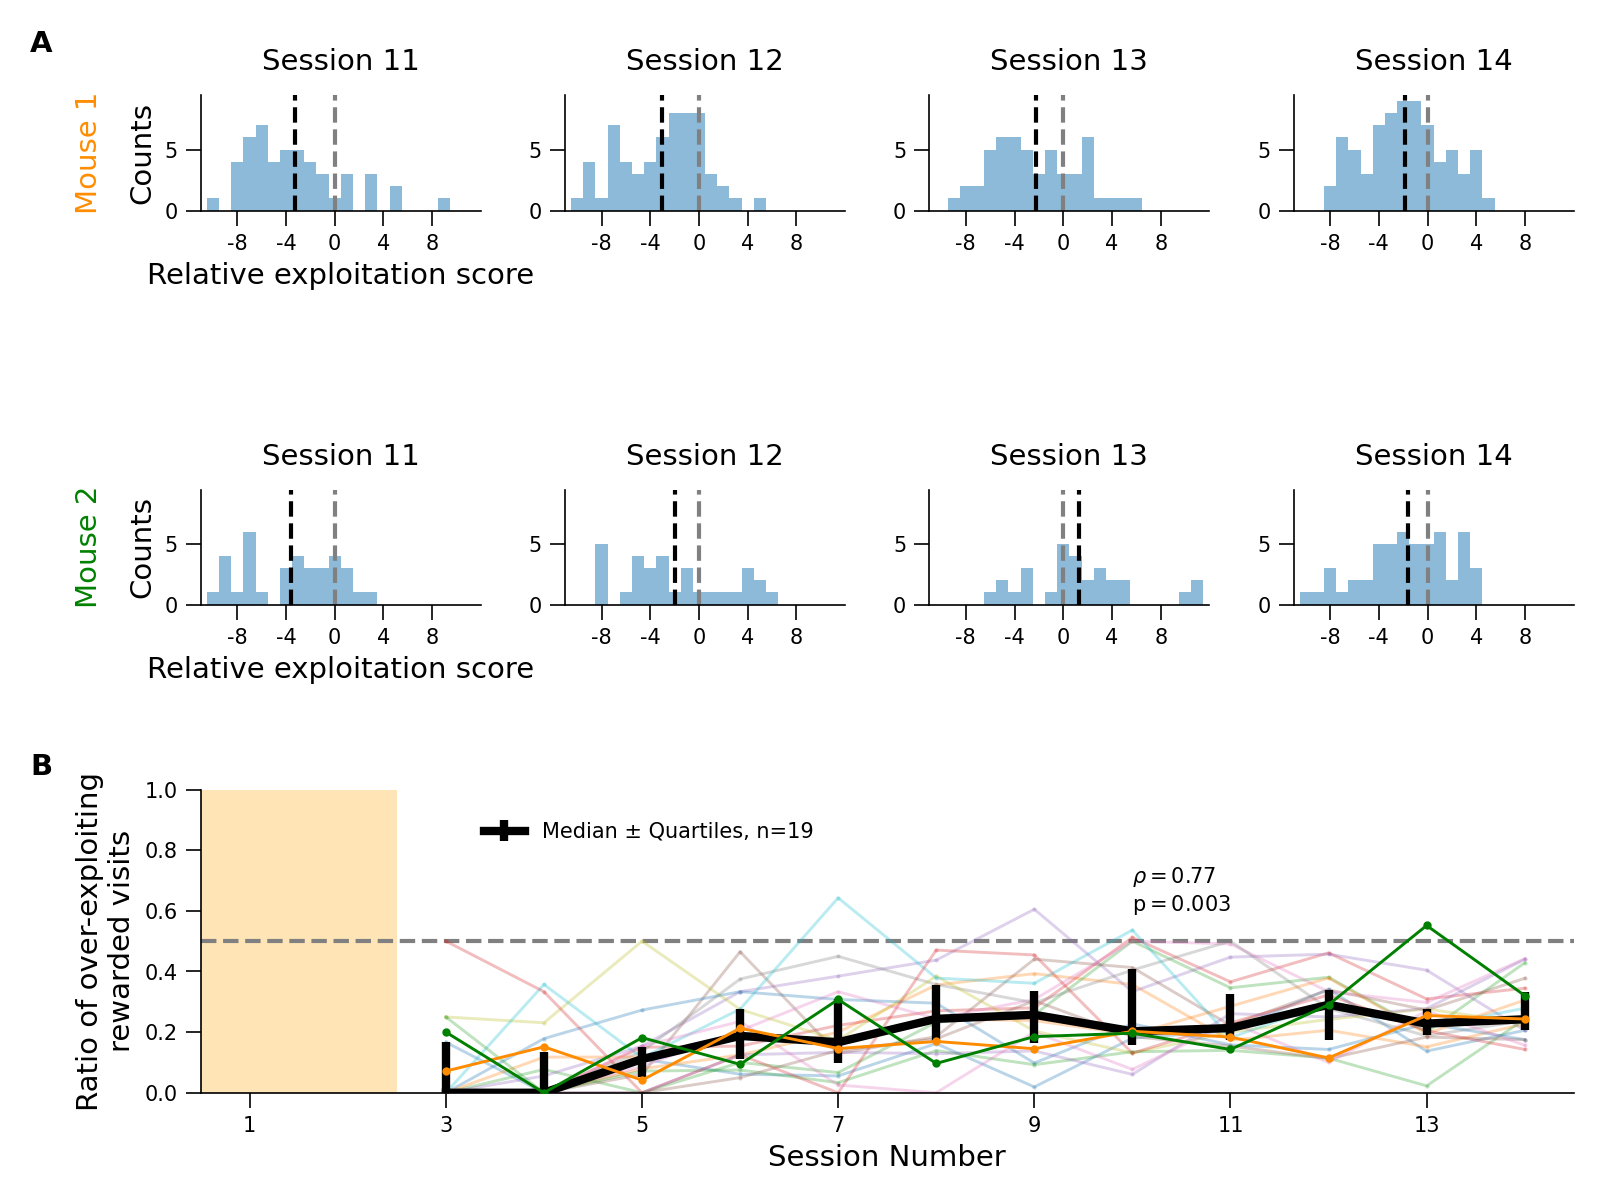

In [ ]:
illustration_sessions_indexes = [10,11,12,13]

fig=plt.figure(figsize=(cm2inch(15), cm2inch(12)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(3, 1 , hspace=0.3)

### Panel A ###

row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
row2 = gs[1].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)
rows = [row1,row2]

ax_lists = [[],[]]

max_xlim = [0,0]
max_ylim = [0,0]

for n, mouse in enumerate(illustration_mice):

    for i in range(len(illustration_sessions_indexes)):

        ax = plt.subplot(rows[n][i], aspect="equal")
        ax_lists[n].append(ax)

        plot_diff_distribution(os.path.join(path_to_data_folder, mouse), illustration_sessions_indexes[i], ax, 
                                            show_xlabel=True if i==0 else False, show_ylabel=True if i==0 else False)
        
        ax.set_title(f"Session {illustration_sessions_indexes[i]+1}", fontsize=7)

        current_xlim = ax.get_xlim()
        current_ylim = ax.get_ylim()

        max_xlim = [min(current_xlim[0],max_xlim[0]), max(current_xlim[1],max_xlim[1])]
        max_ylim = [0, max(current_ylim[1],max_ylim[1])]

        if i==0:
            ax.text(-0.4, 0.5, f'Mouse {n+1}',
                    color=illustration_colors[n],rotation=90, va='center', ha='center',
                    transform=ax.transAxes, fontsize=7)

for n in range(len(illustration_mice)):

    for ax in ax_lists[n]:

        ax.set_xlim(max_xlim)
        ax.set_ylim(max_ylim)

fig.text(0.035, 0.85, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###

row3 = gs[2].subgridspec(1, 1)
ax3 = plt.subplot(row3[0,0])

plot_learning_curves(mouse_overexploit_rewarded_visit_persession, ax3, 
                     mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, 
                     median_color= 'k', show_xlabel = True, xlim=xlim_stats, ylim=(0,1), ylabel='Ratio of over-exploiting\nrewarded visits', 
                     main_line_label=f"Median ± Quartiles, n={len(mice_to_analyse)}", tick_interval=2, index_offset=session_index_offset, show_legend=True, legend_loc=(0.2,0.8))
plot_shuffled_spearman_test_res(ax3, (10,0.6), mouse_overexploit_rewarded_visit_persession, 1000, 'increasing', color='k', first_and_last_session_indexes=first_and_last_session_indexes_stats)

ax3.axhline(0.5, color='grey', linestyle='--', lw=1, zorder=-2000)

fig.text(0.035, 0.34, 'B', weight='bold', va='center', ha='center', fontsize=7)

fig.tight_layout()
plt.savefig("FigureS04.png", facecolor='w', edgecolor='none', format="png", dpi=300)

In [ ]:
# Save the figure as a PDF
fig.savefig("FigureS04.pdf", format="pdf", bbox_inches='tight', dpi=300)
